# Voice under Stress - Analysis

import of all functions needed

In [1]:
import os
import sys

import pandas as pd
import datetime as dt
import imageio
import numpy as np
import subprocess
import matplotlib.pyplot as plt
import seaborn as sns
import scipy 
import math
from statsmodels.stats.descriptivestats import sign_test

from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc, precision_recall_curve, mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold, LeaveOneOut, StratifiedKFold, StratifiedShuffleSplit, train_test_split
from sklearn import metrics, svm, linear_model
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler

from scipy import stats
from scipy.stats import skew, kurtosis
from statsmodels.stats.descriptivestats import sign_test

from matplotlib import rcParams

In [ ]:
homepath=os.getcwd()
scripts_path=os.path.join(homepath, 'scripts')
sys.path.append(scripts_path)

import importlib
import myml
import mystress
import myvoice

importlib.reload(myvoice)
importlib.reload(mystress)
importlib.reload(myml)

In [ ]:

# Check version of Python==64
!python -c "import sys; print(sys.maxsize > 2**32)"

# random seed for reproducability
np.random.seed(42)

# show all columns of dataframes
pd.set_option('display.max_columns', None)

# set current dir to highest hierachy to add data path
os.chdir('/')
data_folder='/data'

sys.path.append(data_folder)
os.chdir(homepath)


True


In [ ]:
filename_librosa='./processed_nemo_data/features.csv'
filename_behavior=data_folder + 'raw/TSST_behavior.csv'
filename_praat='./processed_nemo_data/new_praat_results'
filename_opensmile='./processed_nemo_data/opensmile_features.csv'
filename_output='./processed_nemo_data/df_vpn'

df, librosa_featurenames, praat_featurenames, opensimle_feature=mystress.load_df(filename_opensmile, filename_praat, 
                                                 filename_librosa, filename_behavior, filename_output)
df=mystress.calc_var(df)


In [6]:
pd.set_option('display.max_columns', None)

# Main Code

### Step 1: load data and calculate variables

In [ ]:
df, librosa_featurenames, praat_featurenames, opensimle_feature=mystress.load_df(filename_opensmile, filename_praat, 
                                                 filename_librosa, filename_behavior, filename_output)
df=mystress.calc_var(df)

# In this Notebook we use the data of both conditions (TSST and FTSST)

In [8]:
len(opensimle_feature)

88

In [9]:
audio=praat_featurenames +librosa_featurenames[0:40]+list(opensimle_feature)
audio.append('Sex')

In [10]:
small_audio=['meanF0Hz', 'stdevF0Hz', 'HNR', 'localJitter', 'localShimmer', 'energy', 'Sex']

In [ ]:
#update nachänderung
import importlib
import myvoice
import myml

importlib.reload(myvoice)
importlib.reload(mystress)
importlib.reload(myml)

# Regression

## Random Forest Regressor

### with hyperparameter tuning (max_depth)

Here we are using a LOO (Leave One Out) for regression with a nested 5-fold CV for hyperparameter tuning (GridSearchCV).
In each iteraton the model is tuned on the training data and then predicts the hold out sample. Performance is compared to a mean-baseline and repeated for all folds.

This is done to predict Cortisol_React, cort_20_min, sAA_React, PANA_Delta_NA, PANA_Delta_PA

In [22]:
X, y, vpn= myml.split_and_shuffle(df, audio, 'Cortisol_React')

space = dict()
space['max_depth'] = [2, 4, 5, 10]
model=RandomForestRegressor(n_estimators=1000) 
  
y_pred, y_true, z_test = myml.loo_regression(
    X=X,
    y=y,
    z=vpn,
    model=model,
    name="RF_full_cortisol_react",
    space=space,
    scaling="yes",
    features=audio
)


Shape of X:
(50, 144)
Shape of y:
(50,)
Top 5 Features (gemittelt über alle Folds):
 1. spectrum_39            0.099237 ±   0.026492
 2. spectrum_33            0.084575 ±   0.025210
 3. F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope   0.079298 ±   0.016274
 4. VoicedSegmentsPerSec   0.077077 ±   0.016990
 5. spectrum_9             0.054237 ±   0.013983



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 447.0 pvalue: 0.06633200503891068


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
5.32470693913737
Mean_Absolute_Error:
3.7328842659021206
Standard Deviation of the Error:
3.797114568337126
Spearman Correlation:
Spearman r: 0.20267539 (p=0.15807316)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
5.373623572118887
Mean_Absolute_Error:
4.039713276953469
Standard Deviation of the abs Error:
3.5435218264937505
Saved CSV: RF_full_cortisol_react_loo_abs_error.csv


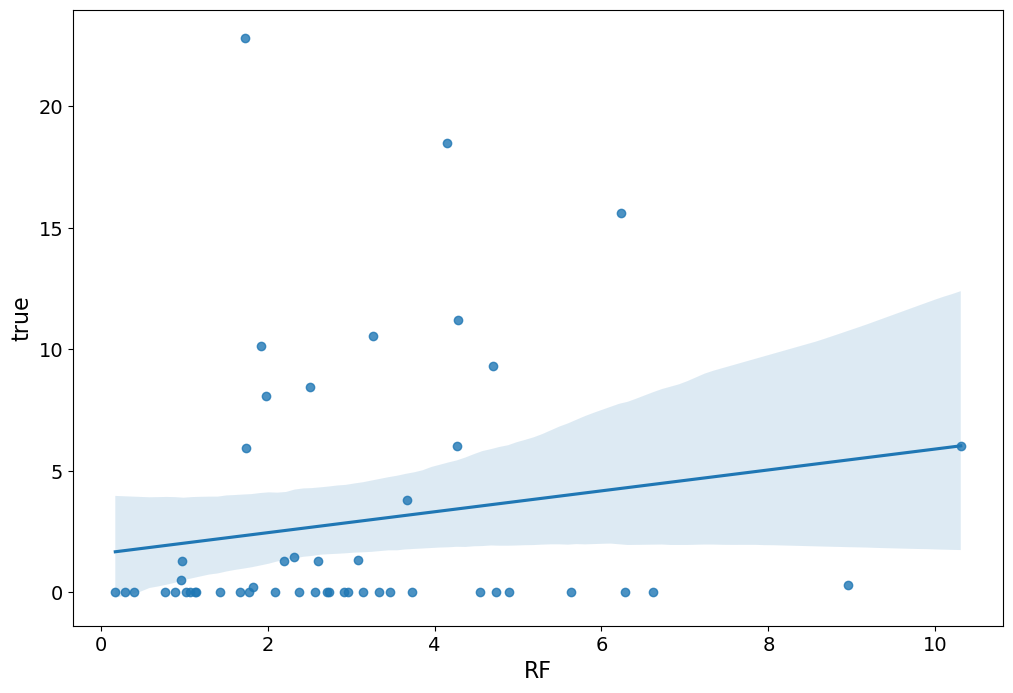

In [23]:
myml.reg_cor(y_pred, y_true, 'RF', 'true')

In [24]:
X, y, vpn= myml.split_and_shuffle(df, audio, 'cort_20_min') 

space = dict()
space['max_depth'] = [2, 4, 5, 10]
model=RandomForestRegressor(n_estimators=1000) 
  
y_pred, y_true, z_test = myml.loo_regression(
    X=X,
    y=y,
    z=vpn,
    model=model,
    name="RF_full_cort_20_min",
    space=space,
    scaling="yes",
    features=audio
)

Shape of X:
(50, 144)
Shape of y:
(50,)
Top 5 Features (gemittelt über alle Folds):
 1. spectrum_39            0.084234 ±   0.020200
 2. F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope   0.059829 ±   0.013099
 3. spectrum_9             0.055866 ±   0.014074
 4. alphaRatioUV_sma3nz_amean   0.055280 ±   0.018771
 5. spectralFlux_sma3_stddevNorm   0.039292 ±   0.010952



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 576.0 pvalue: 0.559104623193516


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
6.5922508325435905
Mean_Absolute_Error:
5.0371701808728435
Standard Deviation of the Error:
4.252609505714943
Spearman Correlation:
Spearman r: 0.09580062 (p=0.50809703)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
6.4480418146006695
Mean_Absolute_Error:
4.928967156303673
Standard Deviation of the abs Error:
4.157225759436017
Saved CSV: RF_full_cort_20_min_loo_abs_error.csv


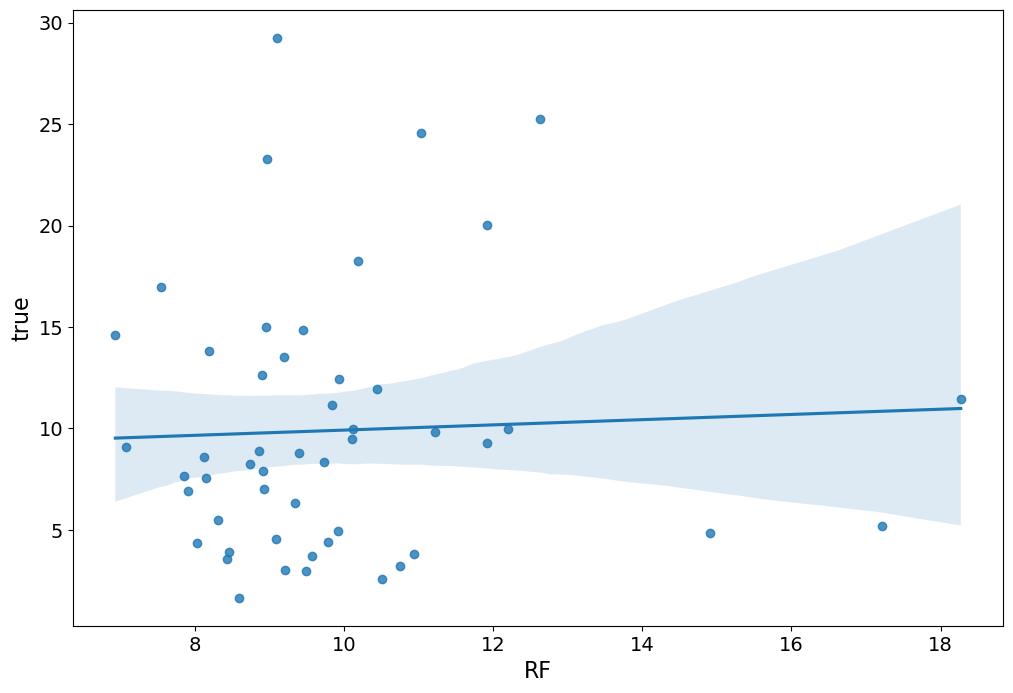

In [25]:
myml.reg_cor(y_pred, y_true, 'RF', 'true')

In [26]:
X, y, vpn= myml.split_and_shuffle(df, audio, 'sAA_React')

space = dict()
space['max_depth'] = [2, 4, 5, 10]
model=RandomForestRegressor(n_estimators=1000) 
  
y_pred, y_true, z_test = myml.loo_regression(
    X=X,
    y=y,
    z=vpn,
    model=model,
    name="RF_full_saa_react",
    space=space,
    scaling="yes",
    features=audio
)

Shape of X:
(50, 144)
Shape of y:
(50,)
Top 5 Features (gemittelt über alle Folds):
 1. F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope   0.291187 ±   0.045479
 2. mfcc4_sma3_amean       0.069998 ±   0.020706
 3. spectrum_33            0.047482 ±   0.013274
 4. shimmerLocaldB_sma3nz_amean   0.045537 ±   0.010725
 5. spectrum_19            0.031553 ±   0.010241



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 512.0 pvalue: 0.22974800885474522


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
43.09509563005969
Mean_Absolute_Error:
32.37395798507117
Standard Deviation of the Error:
28.444931213571888
Spearman Correlation:
Spearman r: 0.20617573 (p=0.15086181)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
48.83843932341892
Mean_Absolute_Error:
37.27356081632652
Standard Deviation of the abs Error:
31.5574843677198
Saved CSV: RF_full_saa_react_loo_abs_error.csv


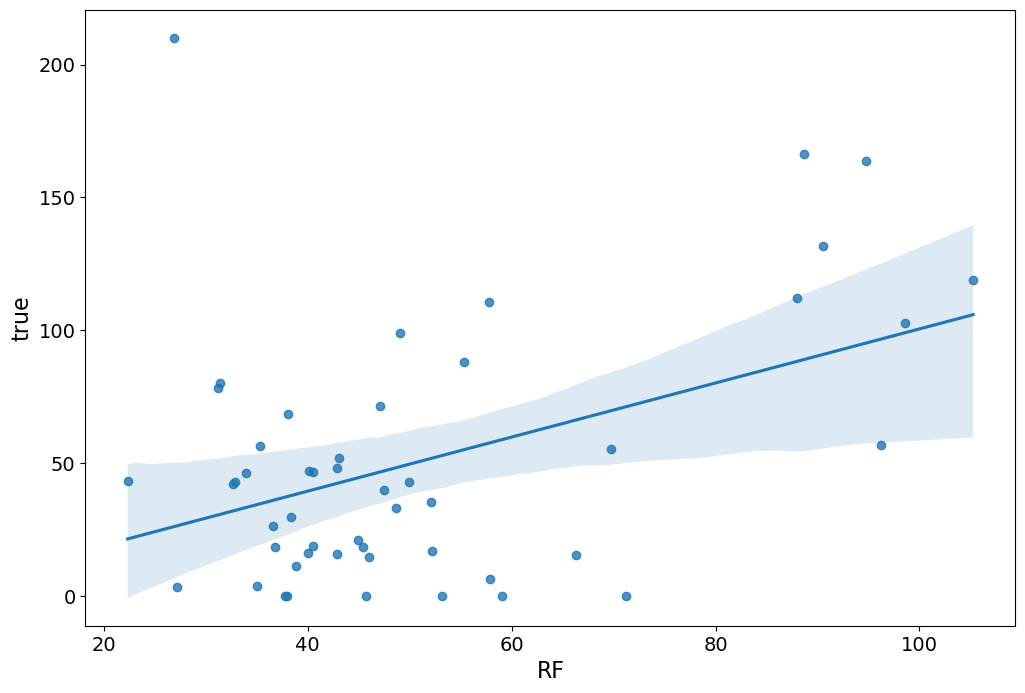

In [27]:
myml.reg_cor(y_pred, y_true, 'RF', 'true')

In [28]:
X, y, vpn= myml.split_and_shuffle(df, audio, 'PANA_Delta_NA') 

space = dict()
space['max_depth'] = [2, 4, 5, 10]
model=RandomForestRegressor(n_estimators=1000) 
  

y_pred, y_true, z_test = myml.loo_regression(
    X=X,
    y=y,
    z=vpn,
    model=model,
    name="RF_full_pana_delta_na",
    space=space,
    scaling="yes",
    features=audio
)

Shape of X:
(50, 144)
Shape of y:
(50,)
Top 5 Features (gemittelt über alle Folds):
 1. loudnessPeaksPerSec    0.246967 ±   0.040739
 2. F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope   0.085118 ±   0.015913
 3. F1bandwidth_sma3nz_amean   0.045208 ±   0.009029
 4. spectrum_21            0.044169 ±   0.010414
 5. F0semitoneFrom27.5Hz_sma3nz_stddevNorm   0.037180 ±   0.007581



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 624.0 pvalue: 0.9010179923007229


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
5.061681566619056
Mean_Absolute_Error:
3.1648540426076646
Standard Deviation of the Error:
3.9502302680781862
Spearman Correlation:
Spearman r: 0.16567780 (p=0.25020328)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
5.053689255752767
Mean_Absolute_Error:
3.1346938775510207
Standard Deviation of the abs Error:
3.9640218702417758
Saved CSV: RF_full_pana_delta_na_loo_abs_error.csv

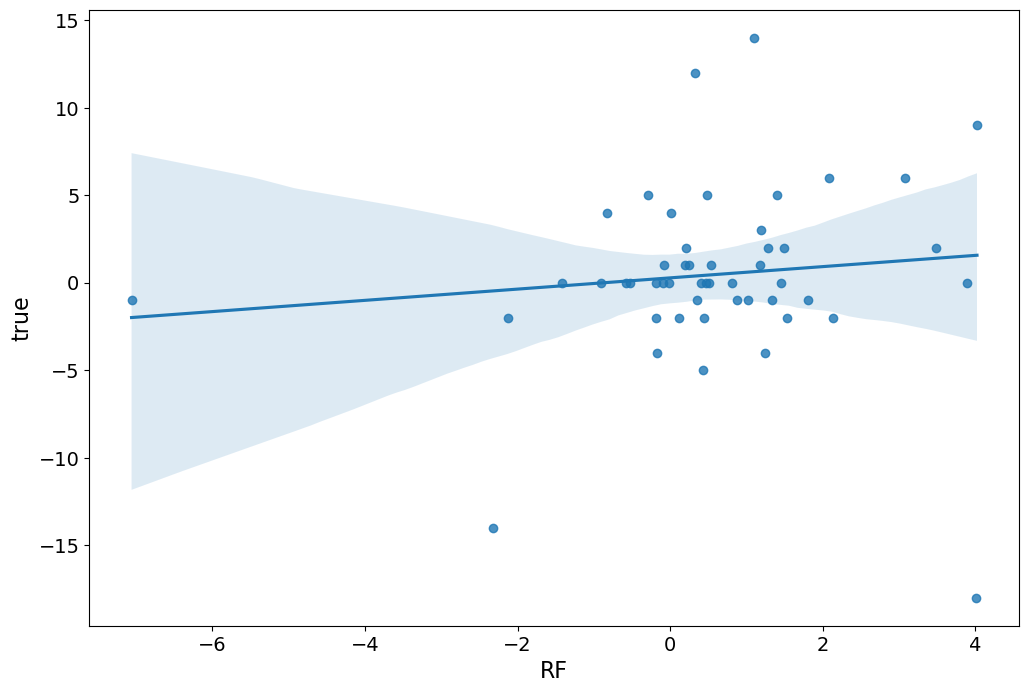

In [29]:
myml.reg_cor(y_pred, y_true, 'RF', 'true')

In [16]:
X, y, vpn= myml.split_and_shuffle(df, audio, 'PANA_Delta_PA') 

space = dict()
space['max_depth'] = [2, 4, 5, 10]
model=RandomForestRegressor(n_estimators=1000) 
  

y_pred, y_true, z_test = myml.loo_regression(
    X=X,
    y=y,
    z=vpn,
    model=model,
    name="RF_full_pana_delta_pa",
    space=space,
    scaling="yes",
    features=audio
)

Shape of X:
(50, 144)
Shape of y:
(50,)
Top 5 Features (gemittelt über alle Folds):
 1. loudnessPeaksPerSec    0.234851 ±   0.052587
 2. spectrum_9             0.056118 ±   0.011604
 3. logRelF0-H1-H2_sma3nz_amean   0.049122 ±   0.012958
 4. spectrum_7             0.028060 ±   0.007889
 5. spectrum_0             0.026271 ±   0.007104



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 603.0 pvalue: 0.7448958960780061


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
5.898086632728885
Mean_Absolute_Error:
4.111691486455191
Standard Deviation of the Error:
4.228642695639707
Spearman Correlation:
Spearman r: -0.09467652 (p=0.51310991)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
5.520172389246289
Mean_Absolute_Error:
3.9330612244897964
Standard Deviation of the abs Error:
3.8734135605963784
Saved CSV: RF_full_pana_delta_pa_loo_abs_error.csv


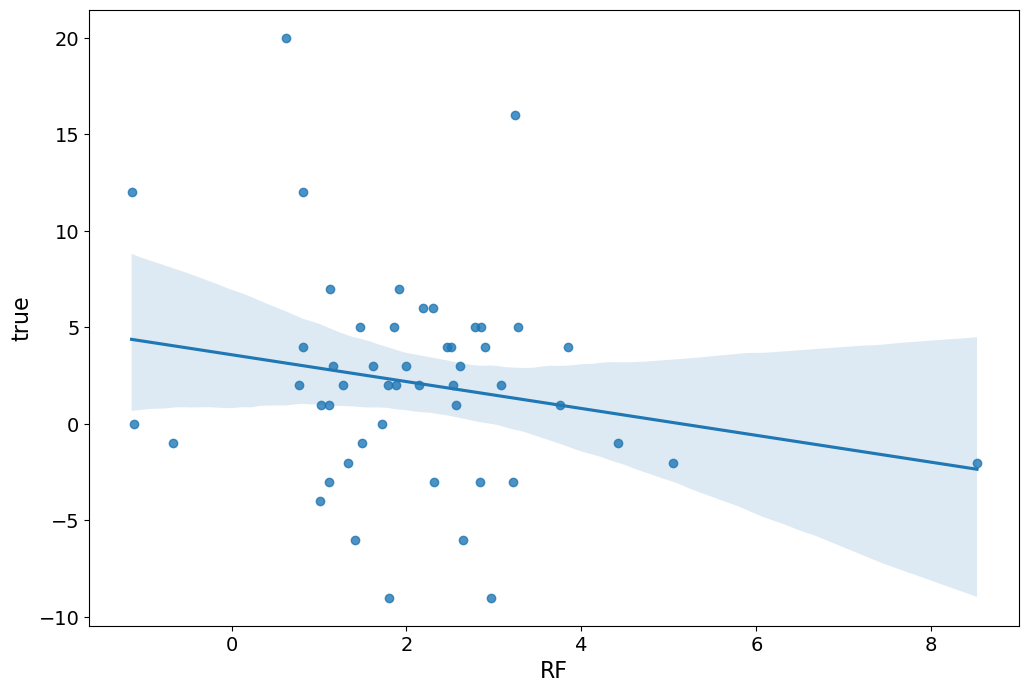

In [17]:
myml.reg_cor(y_pred, y_true, 'RF', 'true')

# Support Vector Machine

### with hyperparameter tuning (Kernel, Epsilon, C)

Here we are using a LOO (Leave One Out) for regression with a nested 5-fold CV for hyperparameter tuning (GridSearchCV).
In each iteraton the model is tuned on the training data and then predicts the hold out sample. Performance is compared to a mean-baseline and repeated for all folds.

This is done to predict Cortisol_React, cort_20_min, sAA_React, PANA_Delta_NA, PANA_Delta_PA

In [18]:
X, y, vpn= myml.split_and_shuffle(df, audio, 'Cortisol_React') #(df, new_features, 'Cortisol_MinMax')

model = SVR(kernel='rbf', gamma='scale')

space = dict()
space['C'] = [10, 1.0, 0.1, 0.01]
space['kernel'] = ['linear', 'rbf']
space['gamma'] = ['scale', 0.001, 0.01, 0.1, 1, 10]

y_pred, y_true, z_test = myml.loo_regression(X, y, vpn, model,"SVR_full_cortisol_react", space, 'yes', audio)

Shape of X:
(50, 144)
Shape of y:
(50,)
Top 5 Features (Permutation Importance, gemittelt über alle Folds):
 1. F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2   0.042466 ±   0.016395
 2. VoicedSegmentsPerSec   0.038561 ±   0.016510
 3. spectrum_17            0.037602 ±   0.011994
 4. spectrum_6             0.035507 ±   0.012307
 5. F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope   0.029664 ±   0.009624



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 312.0 pvalue: 0.0013303578723942167


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
5.6764191235666495
Mean_Absolute_Error:
3.1004487788236297
Standard Deviation of the Error:
4.754887110782362
Spearman Correlation:
Spearman r: 0.00701095 (p=0.96145995)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
5.373623572118887
Mean_Absolute_Error:
4.039713276953469
Standard Deviation of the abs Error:
3.5435218264937505
Saved CSV: SVR_full_cort

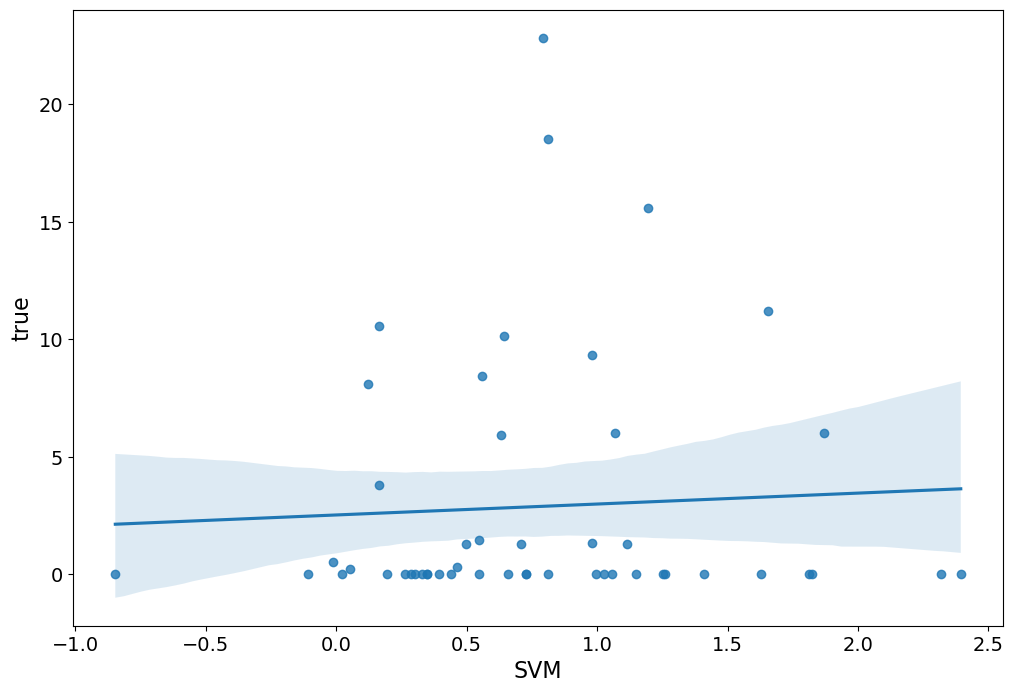

In [19]:
myml.reg_cor(y_pred, y_true, 'SVM', 'true')

In [20]:
X, y, vpn= myml.split_and_shuffle(df, audio, 'cort_20_min') #(df, new_features, 'Cortisol_MinMax')

model = SVR(kernel='rbf', gamma='scale')

space = dict()
space['C'] = [10, 1.0, 0.1, 0.01]
space['kernel'] = ['linear', 'rbf']
space['gamma'] = ['scale', 0.001, 0.01, 0.1, 1, 10]


y_pred, y_true, z_test = myml.loo_regression(X, y, vpn, model, "SVR_full_cort_20_min", space, 'yes', audio)

Shape of X:
(50, 144)
Shape of y:
(50,)
Top 5 Features (Permutation Importance, gemittelt über alle Folds):
 1. spectrum_9             0.045481 ±   0.039849
 2. loudnessPeaksPerSec    0.038280 ±   0.032232
 3. VoicedSegmentsPerSec   0.033931 ±   0.034863
 4. logRelF0-H1-H2_sma3nz_stddevNorm   0.033277 ±   0.048644
 5. spectrum_17            0.033182 ±   0.040240



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 537.0 pvalue: 0.3374027667706141


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
6.559061111016964
Mean_Absolute_Error:
4.779479392864026
Standard Deviation of the Error:
4.491977225147431
Spearman Correlation:
Spearman r: -0.11111911 (p=0.44234397)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
6.4480418146006695
Mean_Absolute_Error:
4.928967156303673
Standard Deviation of the abs Error:
4.157225759436017
Saved CSV: SVR_full_cort_20_min_loo_abs_error.csv


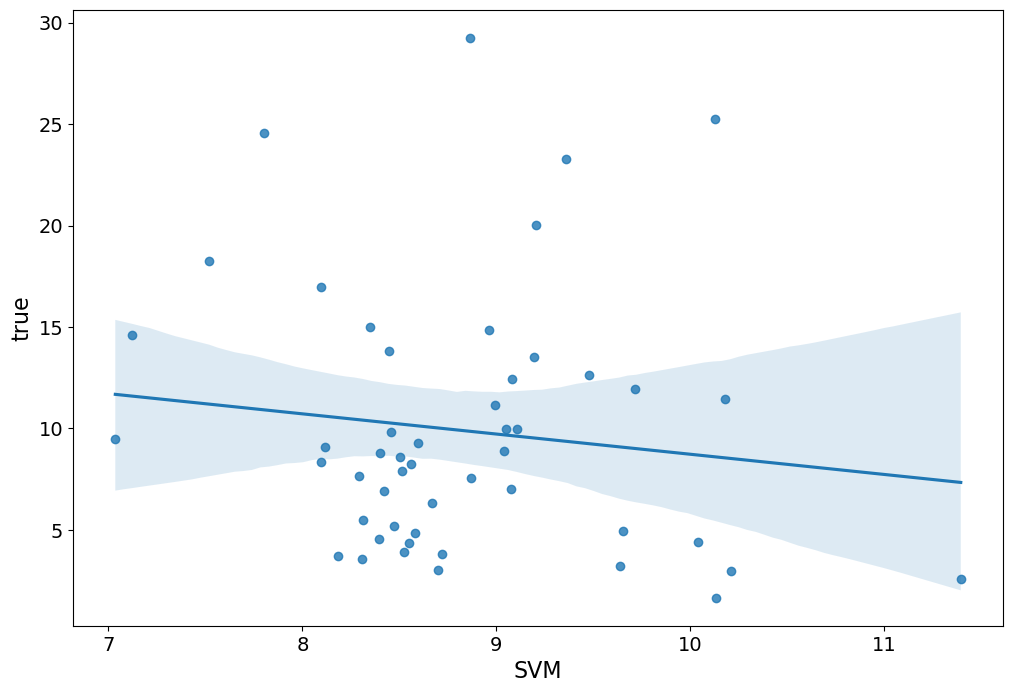

In [21]:
myml.reg_cor(y_pred, y_true, 'SVM', 'true')

In [22]:
X, y, vpn= myml.split_and_shuffle(df, audio, 'sAA_React') #(df, new_features, 'Cortisol_MinMax')

model = SVR(kernel='rbf', gamma='scale')

space = dict()
space['C'] = [10, 1.0, 0.1, 0.01]
space['kernel'] = ['linear', 'rbf']
space['gamma'] = ['scale', 0.001, 0.01, 0.1, 1, 10]

y_pred, y_true, z_test = myml.loo_regression(X, y, vpn, model, "SVR_full_saa_react", space, 'yes', audio)

Shape of X:
(50, 144)
Shape of y:
(50,)
Top 5 Features (Permutation Importance, gemittelt über alle Folds):
 1. F0semitoneFrom27.5Hz_sma3nz_stddevNorm   0.112137 ±   0.704407
 2. loudness_sma3_stddevRisingSlope   0.111752 ±   0.734933
 3. alphaRatioV_sma3nz_amean   0.111693 ±   0.734523
 4. F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope   0.110414 ±   0.723092
 5. loudness_sma3_meanRisingSlope   0.110159 ±   0.724880



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 465.0 pvalue: 0.09709384967839618


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
49.27165028059061
Mean_Absolute_Error:
35.86627336972553
Standard Deviation of the Error:
33.7832200351142
Spearman Correlation:
Spearman r: -0.82033478 (p=0.00000000)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
48.83843932341892
Mean_Absolute_Error:
37.27356081632652
Standard Deviation of the abs Error:
31.5574843677198
Saved CS

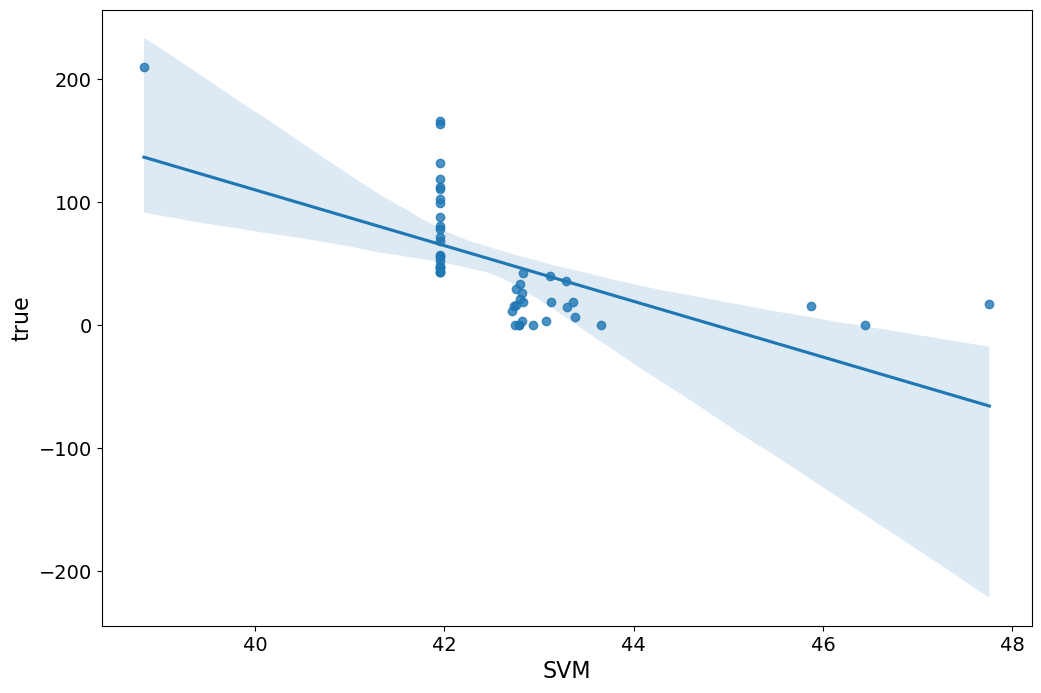

In [23]:
myml.reg_cor(y_pred, y_true, 'SVM', 'true')

In [24]:
X, y, vpn= myml.split_and_shuffle(df, audio, 'PANA_Delta_NA') #(df, new_features, 'Cortisol_MinMax')

model = SVR(kernel='rbf', gamma='scale')

space = dict()
space['C'] = [10, 1.0, 0.1, 0.01]
space['kernel'] = ['linear', 'rbf']
space['gamma'] = ['scale', 0.001, 0.01, 0.1, 1, 10]

y_pred, y_true, z_test = myml.loo_regression(X, y, vpn, model,"SVR_full_pana_delta_na", space, 'yes', audio)

Shape of X:
(50, 144)
Shape of y:
(50,)
Top 5 Features (Permutation Importance, gemittelt über alle Folds):
 1. VoicedSegmentsPerSec   0.300694 ±   0.191370
 2. loudnessPeaksPerSec    0.296745 ±   0.111781
 3. F2bandwidth_sma3nz_stddevNorm   0.212875 ±   0.138560
 4. shimmerLocaldB_sma3nz_stddevNorm   0.175366 ±   0.116799
 5. spectrum_13            0.161689 ±   0.062783



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 552.0 pvalue: 0.4151920088524754


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
4.947815807080125
Mean_Absolute_Error:
3.373242025926305
Standard Deviation of the Error:
3.6196849994601106
Spearman Correlation:
Spearman r: 0.27899540 (p=0.04975663)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
5.053689255752767
Mean_Absolute_Error:
3.1346938775510207
Standard Deviation of the abs Error:
3.9640218702417758
Saved CSV: SVR_full_pana_delta_na_loo_abs_error.csv

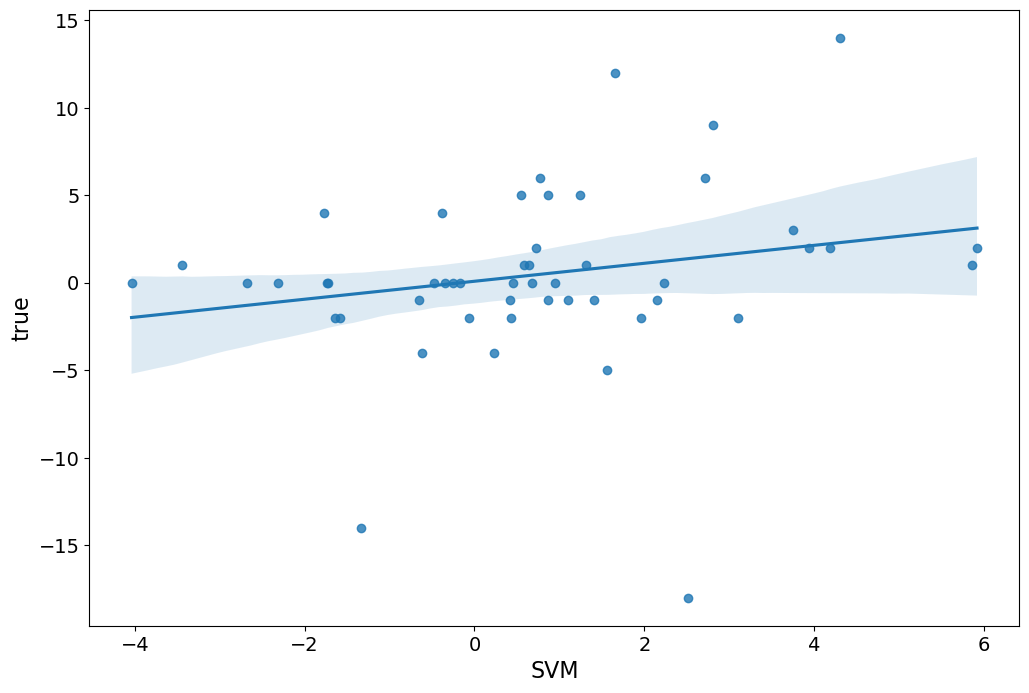

In [25]:
myml.reg_cor(y_pred, y_true, 'SVM', 'true')

In [26]:
X, y, vpn= myml.split_and_shuffle(df, audio, 'PANA_Delta_PA') #(df, new_features, 'Cortisol_MinMax')

model = SVR(kernel='rbf', gamma='scale')

space = dict()
space['C'] = [10, 1.0, 0.1, 0.01]
space['kernel'] = ['linear', 'rbf']
space['gamma'] = ['scale', 0.001, 0.01, 0.1, 1, 10]

y_pred, y_true, z_test = myml.loo_regression(X, y, vpn, model,"SVR_full_pana_delta_pa", space, 'yes', audio)

Shape of X:
(50, 144)
Shape of y:
(50,)
Top 5 Features (Permutation Importance, gemittelt über alle Folds):
 1. spectrum_10            0.042308 ±   0.030524
 2. spectrum_9             0.034771 ±   0.020180
 3. spectrum_16            0.026456 ±   0.016687
 4. mfcc3V_sma3nz_stddevNorm   0.021268 ±   0.015711
 5. spectrum_17            0.016562 ±   0.012247



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 618.0 pvalue: 0.8557483168795788


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
5.510458539318875
Mean_Absolute_Error:
3.961611916092616
Standard Deviation of the Error:
3.8302459894666416
Spearman Correlation:
Spearman r: 0.05328867 (p=0.71321733)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
5.520172389246289
Mean_Absolute_Error:
3.9330612244897964
Standard Deviation of the abs Error:
3.8734135605963784
Saved CSV: SVR_full_pana_delta_pa_loo_abs_error.csv


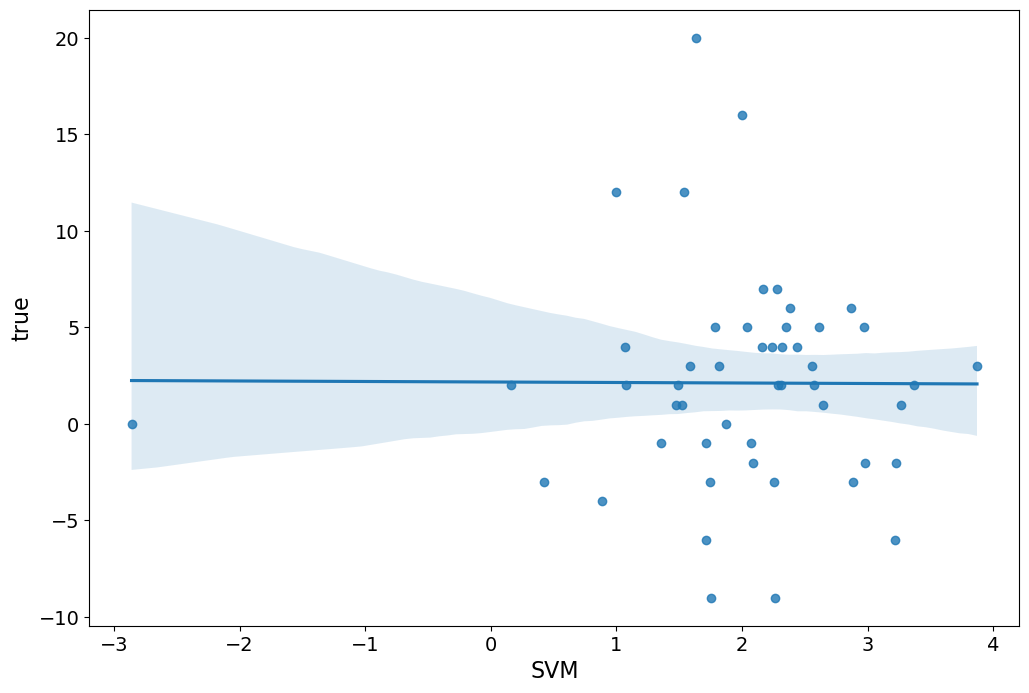

In [27]:
myml.reg_cor(y_pred, y_true, 'SVM', 'true')

# XGBoost

### with hyperparameter tuning (max_depth, learning_rate, n_estimators)

Here we are using a LOO (Leave One Out) for regression with a nested 5-fold CV for hyperparameter tuning (GridSearchCV).
In each iteraton the model is tuned on the training data and then predicts the hold out sample. Performance is compared to a mean-baseline and repeated for all folds.

This is done to predict Cortisol_React, cort_20_min, sAA_React, PANA_Delta_NA, PANA_Delta_PA

In [28]:
from xgboost import XGBRegressor
X, y, vpn= myml.split_and_shuffle(df, audio, 'Cortisol_React')

model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    n_jobs=-1
)

space = dict()
space["max_depth"] = [1, 2, 4, 8]
space["learning_rate"] = [0.03, 0.1, 0.2]
space["n_estimators"] = [50, 100, 150]

y_pred, y_true, z_test = myml.loo_regression(X, y, vpn, model, "XGB_full_cortisol_react", space, 'yes', audio)

Shape of X:
(50, 144)
Shape of y:
(50,)
Top 5 Features (gemittelt über alle Folds):
 1. spectrum_39            0.171619 ±   0.066832
 2. logRelF0-H1-H2_sma3nz_amean   0.142130 ±   0.044022
 3. ppq5Jitter             0.111088 ±   0.037871
 4. loudness_sma3_percentile20.0   0.110541 ±   0.075803
 5. spectrum_9             0.073869 ±   0.040243



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 397.0 pvalue: 0.020238454315462655


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
5.606940869969978
Mean_Absolute_Error:
3.413642545478495
Standard Deviation of the Error:
4.448014218844044
Spearman Correlation:
Spearman r: 0.41588964 (p=0.00266662)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
5.373623572118887
Mean_Absolute_Error:
4.039713276953469
Standard Deviation of the abs Error:
3.5435218264937505
Saved CSV: XGB_full_cortisol_react_loo_abs_error.csv


In [29]:
from xgboost import XGBRegressor
X, y, vpn= myml.split_and_shuffle(df, audio, 'cort_20_min')

model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    n_jobs=-1
)

space = dict()
space["max_depth"] = [1, 2, 4, 8]
space["learning_rate"] = [0.03, 0.1, 0.2]
space["n_estimators"] = [50, 100, 150]

y_pred, y_true, z_test = myml.loo_regression(X, y, vpn, model, "XGB_full_cort_20_min", space, 'yes', audio)

Shape of X:
(50, 144)
Shape of y:
(50,)
Top 5 Features (gemittelt über alle Folds):
 1. alphaRatioUV_sma3nz_amean   0.114866 ±   0.051579
 2. spectrum_33            0.071008 ±   0.043232
 3. F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope   0.070601 ±   0.022943
 4. spectralFlux_sma3_stddevNorm   0.067857 ±   0.028850
 5. logRelF0-H1-H2_sma3nz_amean   0.051393 ±   0.033252



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 511.0 pvalue: 0.2260100302518655


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
7.285037513147037
Mean_Absolute_Error:
5.631263623891074
Standard Deviation of the Error:
4.621757411007281
Spearman Correlation:
Spearman r: -0.08029004 (p=0.57939217)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
6.4480418146006695
Mean_Absolute_Error:
4.928967156303673
Standard Deviation of the abs Error:
4.157225759436017
Saved CSV: XGB_full_cort_20_min_loo_abs_error.csv


In [11]:
from xgboost import XGBRegressor
X, y, vpn= myml.split_and_shuffle(df, audio, 'sAA_React')

model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    n_jobs=-1
)

space = dict()
space["max_depth"] = [1, 2, 4, 8]
space["learning_rate"] = [0.03, 0.1, 0.2]
space["n_estimators"] = [50, 100, 150]

y_pred, y_true, z_test = myml.loo_regression(X, y, vpn, model, "XGB_full_saa_react", space, 'yes', audio)

Shape of X:
(50, 144)
Shape of y:
(50,)
Top 5 Features (gemittelt über alle Folds):
 1. logRelF0-H1-H2_sma3nz_amean   0.196265 ±   0.086782
 2. mfcc4_sma3_amean       0.140647 ±   0.056207
 3. F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope   0.129351 ±   0.058374
 4. F3bandwidth_sma3nz_stddevNorm   0.045015 ±   0.019239
 5. shimmerLocaldB_sma3nz_amean   0.031249 ±   0.048152



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 619.0 pvalue: 0.8632650227005474


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
47.43884674257519
Mean_Absolute_Error:
35.548142465057374
Standard Deviation of the Error:
31.412955091005387
Spearman Correlation:
Spearman r: 0.18084832 (p=0.20881155)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
48.83843932341892
Mean_Absolute_Error:
37.27356081632652
Standard Deviation of the abs Error:
31.5574843677198
Saved CSV: XGB_full_saa_react_loo_abs_error.csv


In [12]:
from xgboost import XGBRegressor
X, y, vpn= myml.split_and_shuffle(df, audio, 'PANA_Delta_NA')

model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    n_jobs=-1
)

space = dict()
space["max_depth"] = [1, 2, 4, 8]
space["learning_rate"] = [0.03, 0.1, 0.2]
space["n_estimators"] = [50, 100, 150]

y_pred, y_true, z_test = myml.loo_regression(X, y, vpn, model, "XGB_full_pana_delta_na", space, 'yes', audio)

Shape of X:
(50, 144)
Shape of y:
(50,)
Top 5 Features (gemittelt über alle Folds):
 1. loudnessPeaksPerSec    0.122258 ±   0.029967
 2. F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope   0.100368 ±   0.059141
 3. spectrum_0             0.065075 ±   0.046202
 4. shimmerLocaldB_sma3nz_stddevNorm   0.058921 ±   0.040459
 5. spectrum_19            0.057709 ±   0.045947



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 615.0 pvalue: 0.8332778036429911


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
4.841360106318045
Mean_Absolute_Error:
3.1008297984302042
Standard Deviation of the Error:
3.7180132114094446
Spearman Correlation:
Spearman r: 0.49003910 (p=0.00030357)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
5.053689255752767
Mean_Absolute_Error:
3.1346938775510207
Standard Deviation of the abs Error:
3.9640218702417758
Saved CSV: XGB_full_pana_delta_na_loo_abs_error.csv


In [12]:
from xgboost import XGBRegressor
X, y, vpn= myml.split_and_shuffle(df, audio, 'PANA_Delta_PA')

model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    n_jobs=-1
)

space = dict()
space["max_depth"] = [1, 2, 4, 8]
space["learning_rate"] = [0.03, 0.1, 0.2]
space["n_estimators"] = [50, 100, 150]

y_pred, y_true, z_test = myml.loo_regression(X, y, vpn, model, "XGB_full_pana_delta_pa", space, 'yes', audio)

Shape of X:
(50, 144)
Shape of y:
(50,)
Top 5 Features (gemittelt über alle Folds):
 1. loudnessPeaksPerSec    0.125408 ±   0.044547
 2. spectrum_0             0.086903 ±   0.041013
 3. jitterLocal_sma3nz_stddevNorm   0.085361 ±   0.037292
 4. spectrum_9             0.084274 ±   0.030287
 5. logRelF0-H1-H2_sma3nz_amean   0.073807 ±   0.029495



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 529.0 pvalue: 0.2999546071877397


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
5.881705262389862
Mean_Absolute_Error:
4.150071150362492
Standard Deviation of the Error:
4.167897100523661
Spearman Correlation:
Spearman r: -0.13293258 (p=0.35741919)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
5.520172389246289
Mean_Absolute_Error:
3.9330612244897964
Standard Deviation of the abs Error:
3.8734135605963784
Saved CSV: XGB_full_pana_delta_pa_loo_abs_error.csv
